In [8]:
import numpy as np
from numpy.random import default_rng
import pandas as pd
import anndata as ad
import squidpy as sq
import matplotlib.pyplot as plt

from anndata import AnnData

## Attention matrix plotting

In [69]:
N = 21  # Adjusting to match the total number of annotated cell types
cell_types = ['A', 'B', 'C']

In [70]:
def create_adata_test(nr_cells = 5000, nr_genes = 100, x = (0,5), y = (0, 5), cell_types = ['A', 'B', 'C']):
    rng = default_rng(42)
    counts = rng.integers(0, 15, size=(nr_cells, nr_genes))  # feature matrix
    cell_per_fov = int(np.ceil(nr_cells/3))
    coordinates_x = rng.uniform(x[0], x[1], [nr_cells])
    coordinates_y = rng.uniform(y[0], y[1], [nr_cells])
    indices = [f'{cell_type}' for cell_type in cell_types for i in range(nr_cells//len(cell_types))]
    print(indices)
    assert len(indices) == nr_cells
    coordinates = np.column_stack((coordinates_x, coordinates_y))
    fov = list("x" * cell_per_fov) + list("y" * cell_per_fov) + list("z" * (nr_cells - (cell_per_fov*2)))
    assert len(fov) == nr_cells
    adata = ad.AnnData(
        counts,
        obs={"fov": fov, "globalX": coordinates_x, "globalY": coordinates_y, "cell_type": indices},
        obsm={"spatial": coordinates},
    )
    adata.obs_names = indices
    return adata

In [71]:
def make_attention_matrix(N, indices):
    # Generate a random attention matrix
    attention_matrix = np.random.rand(N, N)

    # Normalize the rows to sum to 1 (softmax-like normalization)
    attention_matrix = attention_matrix / attention_matrix.sum(axis=1, keepdims=True)

    # Create a DataFrame
    attention_df = pd.DataFrame(attention_matrix, index=indices, columns=indices)

    return attention_df

In [72]:
adata = create_adata_test(nr_cells = N, nr_genes = 5, x = (0,5), y = (0, 5), cell_types = ['A', 'B', 'C'])

['A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'C', 'C', 'C', 'C', 'C', 'C', 'C']


In [73]:
attention_df = make_attention_matrix(N, indices=adata.obs_names)
attention_df

,A,A,A,A,A,A,A,B,B,B,...,B,B,B,C,C,C,C,C,C,C
A,0.027435,0.009059,0.053237,0.010175,0.016533,0.099408,0.077876,0.045821,0.010525,0.057573,...,0.007534,0.010544,0.072778,0.082341,0.092161,0.076736,0.035408,0.083135,0.093449,0.033435
A,0.067112,0.057516,0.044179,0.031717,0.019511,0.044726,0.025102,0.003330,0.087045,0.083001,...,0.017834,0.049022,0.072074,0.000156,0.063212,0.063767,0.069467,0.026411,0.085512,0.030194
A,0.052186,0.053341,0.044379,0.057934,0.061261,0.063719,0.011508,0.036179,0.052248,0.045004,...,0.016820,0.020746,0.080348,0.056257,0.080475,0.030723,0.050356,0.051337,0.053833,0.009039
A,0.059078,0.021729,0.014839,0.062153,0.060135,0.072886,0.015184,0.066796,0.048901,0.043666,...,0.016220,0.072901,0.057177,0.075931,0.061614,0.049009,0.004793,0.059050,0.068105,0.045648
A,0.051152,0.006935,0.067943,0.023908,0.095942,0.033853,0.033436,0.022126,0.096271,0.043476,...,0.035869,0.053705,0.089072,0.012164,0.065039,0.075925,0.053813,0.072525,0.010506,0.045874
A,0.035351,0.018052,0.047595,0.077443,0.086994,0.008567,0.057127,0.014093,0.001072,0.099097,...,0.081967,0.054934,0.088119,0.078876,0.060293,0.024202,0.083666,0.036462,0.001415,0.029406
A,0.026307,0.045429,0.058226,0.069020,0.009370,0.008606,0.044725,0.012090,0.058556,0.066496,...,0.030564,0.071517,0.054476,0.084629,0.024091,0.043802,0.069783,0.082163,0.047802,0.045472
B,0.021870,0.037891,0.065620,0.047988,0.019628,0.009720,0.021713,0.049444,0.073054,0.063677,...,0.045917,0.083689,0.063320,0.027656,0.049210,0.075144,0.094948,0.002180,0.034571,0.022933
B,0.069694,0.024069,0.022186,0.076006,0.031495,0.063199,0.041361,0.023798,0.060741,0.079498,...,0.022844,0.038251,0.010187,0.025427,0.075656,0.054259,0.067644,0.060778,0.072060,0.056263
B,0.067941,0.054217,0.079486,0.040777,0.026606,0.046861,0.070483,0.046887,0.079102,0.068759,...,0.009990,0.080799,0.043443,0.073064,0.013798,0.047930,0.016160,0.018959,0.001460,0.073627


In [74]:
# for each cell calculate the vector signal as a sum of pointing 

send_indices = np.argsort(attention_df, axis = 1)[:,-3:]
spatial_coords = adata.obsm['spatial']
spatial_coords

array([[3.32425428, 0.29151371],
       [3.52582689, 1.40691946],
       [3.90364516, 1.46796879],
       [2.29457888, 3.30958257],
       [2.84370598, 2.78516076],
       [0.69898499, 3.91949105],
       [0.57265037, 3.3215677 ],
       [3.34201481, 2.03193431],
       [2.35548103, 4.07010192],
       [2.82618053, 0.8348646 ],
       [3.82499429, 0.11356037],
       [3.1735916 , 0.4502393 ],
       [2.767897  , 3.61179675],
       [2.7960358 , 2.30938615],
       [1.51975049, 0.8063589 ],
       [0.15408917, 2.50522388],
       [2.18358695, 0.76156051],
       [1.07292336, 3.48160188],
       [2.04264322, 2.23078138],
       [4.26701537, 1.90510613],
       [1.16969743, 1.50756045]])

In [75]:
adata.obsm['attention_matrix'] = attention_df

In [76]:
sender_indices = adata.obs.index[adata.obs['cell_type'] == 'A']
print(sender_indices)
receiver_indices = adata.obs.index[adata.obs['cell_type'] == 'B']

attention_df.loc['A', 'B'].sum(axis=1)

Index(['A', 'A', 'A', 'A', 'A', 'A', 'A'], dtype='object')


A    0.209613
A    0.371418
A    0.323652
A    0.329847
A    0.350985
A    0.354550
A    0.340575
dtype: float64

In [77]:
def sender_receiver_stream(adata, sender_cell_type, receiver_cell_type, density = None):
    sender_spatial = adata.obsm['spatial'][adata.obs['cell_type'] == sender_cell_type]
    receiver_spatial = adata.obsm['spatial'][adata.obs['cell_type'] == receiver_cell_type] 
    spatial = adata.obsm['spatial'][adata.obs['cell_type'].isin([sender_cell_type, receiver_cell_type])] 
    attention_matrix = adata.obsm['attention_matrix']
    S, n_dim = sender_spatial.shape
    R = receiver_spatial.shape[0]
    density = 1 if density is None else density

    # Determine the range of data
    grs = []
    for dim_i in range(n_dim):
        m, M = np.min(spatial[:, dim_i]), np.max(spatial[:, dim_i])
        m = m - 0.01 * np.abs(M - m)
        M = M + 0.01 * np.abs(M - m)
        gr = np.linspace(m, M, int(50 * density))
        grs.append(gr)

    # Generate grid
    X, Y = np.meshgrid(*grs)
    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(S):
        for j in range(R):
            # Get sender and receiver coordinates
            sender_x, sender_y = sender_spatial[i]
            receiver_x, receiver_y = receiver_spatial[j]
            
            # Get attention value
            attention_value = attention_matrix.iloc[i, j]
            
            # Compute the vector components
            u = attention_value * (receiver_x - sender_x)
            v = attention_value * (receiver_y - sender_y)
            
            # Add the components to the grid
            U += u / ((X - sender_x)**2 + (Y - sender_y)**2 + 1e-6)
            V += v / ((X - sender_x)**2 + (Y - sender_y)**2 + 1e-6)

    return X, Y, U, V

In [78]:
def plot_attention_sender_receiver(
        adata: AnnData,
        sender_cell_type: str,
        receiver_cell_type: str, 
        cell_type: str = 'cell_type',
        att_matrix_key: str ='attention',
        save_img: str = None,
        add_streamline: bool = False
    ):
    """
    Plot the spatial scatter plot of sender and receiver cells, highlighting the sender cells based on the sum 
    of their attention values towards the receiver cells.

    Parameters
        ----------
        adata: AnnData
            Annotated data matrix.
        sender_cell_type: str
            The cell type considered as the sender in the attention matrix.
        receiver_cell_type: str
            The cell type considered as the receiver in the attention matrix.
        cell_type_col: str, optional (default: 'cell_type')
            The column in adata.obs that contains the cell type information.
        obsm_key: str, optional (default: 'attention')
            The key in adata.obsm that contains the attention matrix.
    """

    # Extract the attention matrix from .obsm
    attention_matrix = adata.obsm[att_matrix_key]
    
    # Extract indices for sender and receiver cells
    sender_indices = adata.obs.index[adata.obs[cell_type] == sender_cell_type]
    receiver_indices = adata.obs.index[adata.obs[cell_type] == receiver_cell_type]

    # Compute the sum of attention values for each sender cell towards all receiver cells
    attention_sums = attention_matrix.loc[sender_cell_type, receiver_cell_type].sum(axis=1)

    subadata = adata[adata.obs[cell_type].isin([sender_cell_type, receiver_cell_type])]

    subadata.obs['attention_values'] = 0
    subadata.obs.loc[subadata.obs[cell_type] == sender_cell_type, 'attention_values'] = attention_sums.values

    # Create a color array initialized to grey for all cells
    cell_colors = [None] * subadata.n_obs
    # Update the colors for sender cells based on their attention sums
    for idx, value in enumerate(subadata.obs['attention_values']):
        if value == 0:
            cell_colors[idx] = (211/255, 211/255, 211/255, 1.0)
        else:
            cell_colors[idx] = plt.cm.summer(value / attention_sums.max())

    subadata.obs['colors'] = cell_colors
    
    fig, ax = plt.subplots()
    sq.pl.spatial_scatter(subadata, shape=None, color='colors', ax=ax, palette=[cell_colors], img = False, size_key = 2)

    if add_streamline:
        X, Y, U, V = sender_receiver_stream(adata, sender_cell_type, receiver_cell_type, density = None)
        ax.streamplot(X, Y, U, V, density=0.5, linewidth=1, arrowsize=1.5)
    

    # Save the plot if a path or filename is provided
    if save_img:
        fig.savefig(save_img, bbox_inches='tight')
    
    plt.show()

/tmp/ipykernel_3655403/1937772515.py:40: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  subadata.obs['attention_values'] = 0
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/tmp/ipykernel_3655403/1937772515.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.20961263 0.37141829 0.32365239 0.32984675 0.350985   0.35455012
 0.34057455]' has dtype incompatible wit

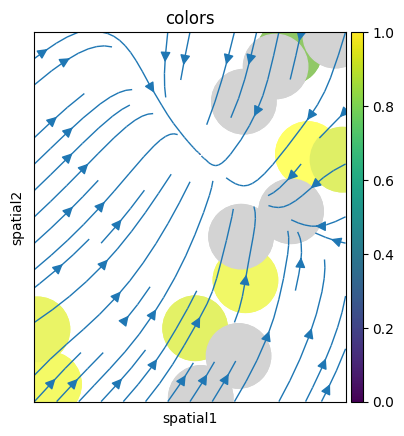

In [79]:
plot_attention_sender_receiver(adata, 'A', 'B', att_matrix_key='attention_matrix', add_streamline = True)

## Streamline plot: Sender to receiver

Inspiration: 
https://github.com/zcang/COMMOT/blob/main/commot/_utils/_plotting.py#L215

- plot_cell_signaling
  - X = adata.obsm["spatial"][:,pos_idx],
  - V = value matrix receiver or sender

In [13]:
sender_cell_type = 'A'
receiver_cell_type = 'B'

In [184]:
sender_indices = adata.obs.index[adata.obs['cell_type'] == sender_cell_type]
receiver_indices = adata.obs.index[adata.obs['cell_type'] == receiver_cell_type]

sender_indices, receiver_indices

(Index(['A', 'A', 'A'], dtype='object'),
 Index(['B', 'B', 'B'], dtype='object'))

In [203]:
att_matrix_s_r = attention_df.loc[sender_cell_type, receiver_cell_type]
att_matrix_s_r

,B,B,B
A,0.097058,0.053033,0.179639
A,0.128265,0.093382,0.116586
A,0.030677,0.104735,0.165800


In [204]:
receiver_col_id = [i for i, col in enumerate(attention_df.columns) if col == 'B']
receiver_col_id

[3, 4, 5]

In [205]:
# indices for top_k highest receiver cells
receiver_indices = np.argsort(att_matrix_s_r, axis = 1)[:,-3:]
receiver_indices

array([[1, 0, 2],
       [1, 2, 0],
       [0, 1, 2]])

In [33]:
attention_matrix = adata.obsm['attention_matrix']
attention_matrix.iloc[0,0]

0.30536365444645086

In [ ]:
def sender_receiver_stream_plot(adata, sender_cell_type, receiver_cell_type, density = None):
    sender_spatial = adata.obsm['spatial'][adata.obs['cell_type'] == sender_cell_type]
    receiver_spatial = adata.obsm['spatial'][adata.obs['cell_type'] == receiver_cell_type] 
    attention_matrix = adata.obsm['attention_matrix']
    S, n_dim = sender_spatial.shape
    R = receiver_spatial.shape[0]
    density = 1 if density is None else density

    # Determine the range of data
    grs = []
    for dim_i in range(n_dim):
        m, M = np.min(sender_spatial[:, dim_i]), np.max(sender_spatial[:, dim_i])
        m = m - 0.01 * np.abs(M - m)
        M = M + 0.01 * np.abs(M - m)
        gr = np.linspace(m, M, int(50 * density))
        grs.append(gr)

    # Generate grid
    X, Y = np.meshgrid(*grs)
    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(S):
        for j in range(R):
            # Get sender and receiver coordinates
            sender_x, sender_y = sender_spatial[i]
            receiver_x, receiver_y = receiver_spatial[j]
            
            # Get attention value
            attention_value = attention_matrix.iloc[i, j]
            
            # Compute the vector components
            u = attention_value * (receiver_x - sender_x)
            v = attention_value * (receiver_y - sender_y)
            
            # Add the components to the grid
            U += u / ((X - sender_x)**2 + (Y - sender_y)**2 + 1e-6)
            V += v / ((X - sender_x)**2 + (Y - sender_y)**2 + 1e-6)

    # Plot the streamplot
    plt.figure(figsize=(10, 8))
    plt.streamplot(X, Y, U, V, density=1.0, linewidth=1, arrowsize=1.5)
    plt.scatter(sender_spatial[:, 0], sender_spatial[:, 1], color='blue', label='Senders')
    plt.scatter(receiver_spatial[:, 0], receiver_spatial[:, 1], color='red', label='Receivers')
    plt.legend()
    plt.title('Attention Streamplot from Senders to Receivers')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.show()

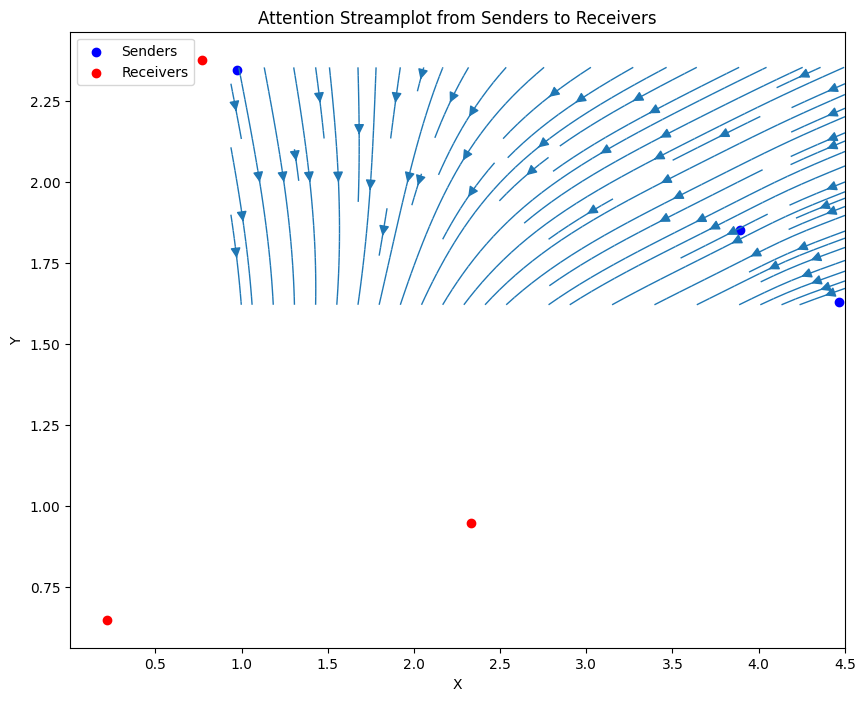

In [47]:
sender_receiver_stream_plot(adata, 'A', 'B')

In [11]:
spatial_coords = adata.obsm['spatial']
spatial_coords

array([[4.46560561, 1.62912679],
       [3.89191749, 1.85229853],
       [0.97319354, 2.34777906],
       [2.33360502, 0.9473568 ],
       [0.21901883, 0.64960753],
       [0.77144746, 2.37852463],
       [3.41524477, 1.13454675],
       [3.72381078, 3.34906997],
       [4.83754866, 2.18575959]])

In [28]:
sender_spatial[:,1]

array([1.62912679, 1.85229853, 2.34777906])

In [26]:
np.meshgrid(sender_spatial[:,0], sender_spatial[:,1])

[array([[4.46560561, 3.89191749, 0.97319354],
        [4.46560561, 3.89191749, 0.97319354],
        [4.46560561, 3.89191749, 0.97319354]]),
 array([[1.62912679, 1.62912679, 1.62912679],
        [1.85229853, 1.85229853, 1.85229853],
        [2.34777906, 2.34777906, 2.34777906]])]

In [24]:
def make_meshgrid(X):
    """
    X: spatial coordinates
    """
    grid_density = 1

    # Get a rectangular grid
    xl, xr = np.min(X[:,0]), np.max(X[:,0])
    epsilon = 0.02*(xr-xl); xl -= epsilon; xr += epsilon
    yl, yr = np.min(X[:,1]), np.max(X[:,1])
    epsilon = 0.02*(yr-yl); yl -= epsilon; yr += epsilon
    ngrid_x = int(50 * grid_density)
    gridsize = (xr-xl) / float(ngrid_x)
    ngrid_y = int((yr-yl)/gridsize)
    meshgrid = np.meshgrid(np.linspace(xl,xr,ngrid_x), np.linspace(yl,yr,ngrid_y))
    grid_pts = np.concatenate((meshgrid[0].reshape(-1,1), meshgrid[1].reshape(-1,1)), axis=1)
    return grid_pts

In [25]:
make_meshgrid(spatial_coords)

array([[0.12664823, 0.59561828],
       [0.22467417, 0.59561828],
       [0.32270011, 0.59561828],
       ...,
       [4.73386738, 3.40305922],
       [4.83189332, 3.40305922],
       [4.92991926, 3.40305922]])